# Network And Career Profiling

Notebook de profiling visual para validar hipoteses antes de promovelas para marts ou para o Streamlit.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / 'linkedin_career_intelligence').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from linkedin_career_intelligence.streamlit_utils import run_query

2026-05-01 16:34:30.528 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


In [2]:
connections = run_query(
    """
    select connection_year_month, total_connections, connections_with_email
    from main.mart_connections_summary
    order by connection_year_month
    """
)

career = run_query(
    """
    select start_year_month, total_positions_started, avg_duration_months
    from main.mart_career_progression
    order by start_year_month
    """
)

connections.head(), career.head()

(  connection_year_month  total_connections  connections_with_email
 0               2025-02                  1                     1.0
 1               2025-03                  1                     0.0,
   start_year_month  total_positions_started  avg_duration_months
 0          2022-01                        1                 17.0
 1          2023-07                        1                 34.0)

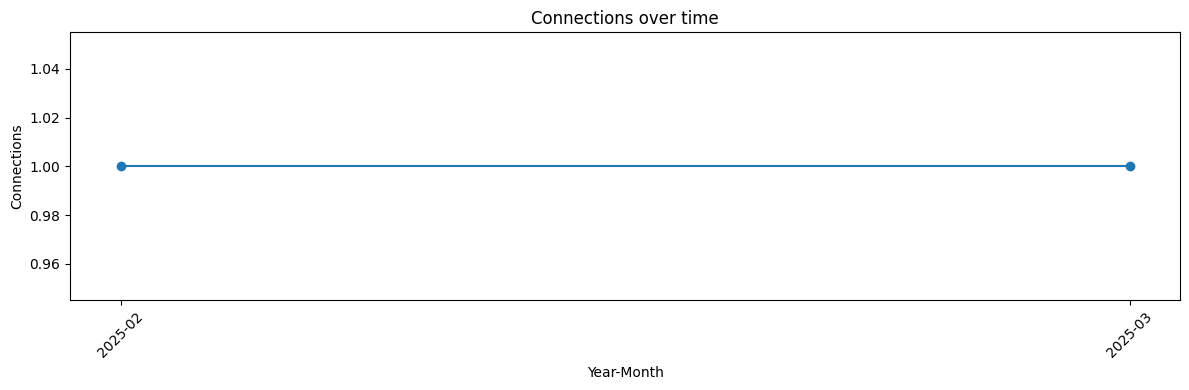

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(connections["connection_year_month"], connections["total_connections"], marker="o")
ax.set_title("Connections over time")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Connections")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

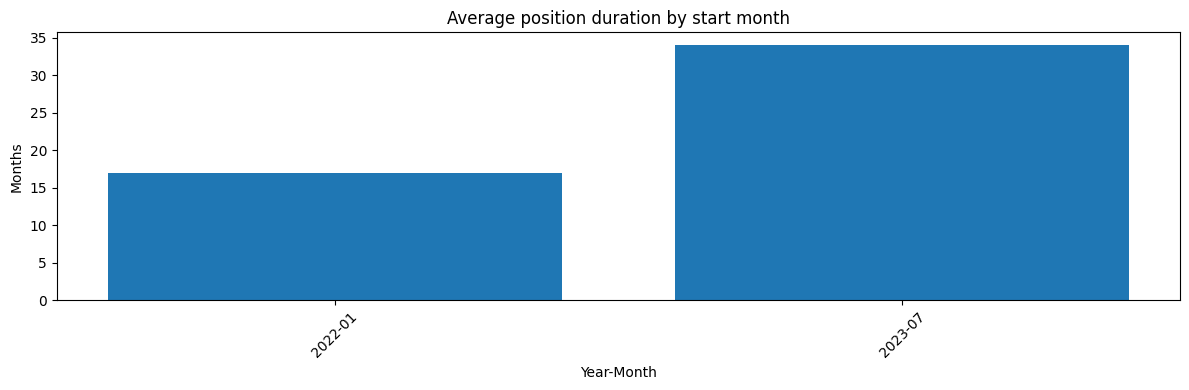

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(career["start_year_month"], career["avg_duration_months"])
ax.set_title("Average position duration by start month")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

In [5]:
connections.assign(
    email_share=lambda df: (df["connections_with_email"] / df["total_connections"]).fillna(0)
).sort_values("email_share", ascending=False).head(10)

,connection_year_month,total_connections,connections_with_email,email_share
0,2025-02,1,1.0,1.0
1,2025-03,1,0.0,0.0
